# 04 — HNSW Parameter Tuning

## From the AWS Slide Deck: Performance Tuning Deep-Dive

> *"ef_search is the most under-tuned parameter — start at 100, raise until recall plateaus."*

This notebook gives you **quantitative intuition** for the three HNSW knobs using real Bedrock embeddings + Qdrant.

| Parameter | Controls | Affects |
|-----------|----------|---------|
| `ef_search` | Query-time candidate pool | Recall ↔ Latency (query time only) |
| `m` | Graph connectivity (edges per node) | Recall + Memory ↔ Index build time |
| `ef_construct` | Build-time candidate pool | Index quality ↔ Build time |

**Stack:** Bedrock Titan V2 (1024-dim) · Qdrant (cloud or in-memory) · matplotlib

## Step 1 — Install & Import

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet',
    'boto3', 'qdrant-client', 'numpy', 'matplotlib', 'python-dotenv'])
print('Packages ready.')

Packages ready.


In [2]:
from dotenv import load_dotenv
load_dotenv('../../../.env')

import os, json, time, uuid
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import boto3

from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct,
    HnswConfigDiff, SearchParams
)

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#3a3d4d', 'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#a0a0b0', 'ytick.color': '#a0a0b0',
    'text.color': '#e0e0e0', 'grid.color': '#2a2d3d',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'figure.dpi': 130, 'axes.titlesize': 12, 'axes.labelsize': 10,
})
print('Imports OK.')

Imports OK.


## Step 2 — Configuration & Bedrock Embedding Helper

In [3]:
AWS_REGION      = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')
EMBEDDING_MODEL = 'amazon.titan-embed-text-v2:0'
EMBEDDING_DIM   = 1024
QDRANT_URL      = os.getenv('QDRANT_URL', '')
QDRANT_API_KEY  = os.getenv('QDRANT_API_KEY', '')

bedrock_rt = boto3.client('bedrock-runtime', region_name=AWS_REGION)

def embed(text: str) -> np.ndarray:
    body = json.dumps({'inputText': text, 'dimensions': EMBEDDING_DIM, 'normalize': True})
    resp = bedrock_rt.invoke_model(
        modelId=EMBEDDING_MODEL, body=body,
        contentType='application/json', accept='application/json'
    )
    return np.array(json.loads(resp['body'].read())['embedding'], dtype=np.float32)

# Smoke test
v = embed('test')
print(f'Embedding dim={v.shape[0]}, norm={np.linalg.norm(v):.4f}')

Embedding dim=1024, norm=1.0000


## Step 3 — Build 50-Sentence Corpus & Embed via Bedrock

In [4]:
CORPUS = [
    # Science
    'The theory of relativity changed our understanding of space and time.',
    'Quantum mechanics describes the behaviour of particles at subatomic scales.',
    'DNA carries genetic information using four nucleotide bases.',
    'Black holes are regions where gravity prevents even light from escaping.',
    'The speed of light in a vacuum is approximately 300,000 km per second.',
    'Photosynthesis converts sunlight into chemical energy in plants.',
    'Electrons orbit the nucleus of an atom in discrete energy levels.',
    'Climate change is accelerated by greenhouse gas emissions.',
    'Tectonic plates move slowly and cause earthquakes at their boundaries.',
    'The human genome contains approximately 3 billion base pairs.',
    # Technology
    'Machine learning models learn patterns from training data.',
    'Neural networks are inspired by the structure of the human brain.',
    'Cloud computing delivers computing resources over the internet.',
    'Blockchain is a distributed ledger technology for secure transactions.',
    'The internet of things connects everyday devices to the internet.',
    'Natural language processing enables computers to understand human text.',
    'Cybersecurity protects systems and networks from digital attacks.',
    'Containerisation with Docker simplifies application deployment.',
    'GraphQL is an API query language that returns exactly the data requested.',
    'Kubernetes orchestrates containerised workloads across clusters.',
    # History
    'The Roman Empire fell in 476 AD marking the end of antiquity.',
    'The French Revolution began in 1789 with the storming of the Bastille.',
    'World War II ended in 1945 with the defeat of Nazi Germany and Imperial Japan.',
    'The printing press was invented by Gutenberg around 1440.',
    'The Industrial Revolution transformed manufacturing in the 18th century.',
    'The Moon landing occurred on July 20 1969 with Apollo 11.',
    'The Berlin Wall fell on November 9 1989 ending the Cold War division.',
    'The Black Death killed a third of Europe\'s population in the 14th century.',
    'The Magna Carta of 1215 limited royal power in England.',
    'The Silk Road connected China and Europe for centuries of trade.',
    # Health
    'Regular exercise reduces the risk of heart disease and diabetes.',
    'Vaccines stimulate the immune system to fight specific pathogens.',
    'Sleep deprivation impairs cognitive function and immune health.',
    'A balanced diet rich in vegetables supports long-term wellbeing.',
    'Antibiotics treat bacterial infections but are ineffective against viruses.',
    'The gut microbiome plays a key role in digestion and immunity.',
    'Stress hormones like cortisol can disrupt sleep and metabolism.',
    'MRI uses magnetic fields to produce detailed images of soft tissue.',
    'Smoking is the leading preventable cause of cancer worldwide.',
    'Insulin regulates blood sugar levels in the human body.',
    # Art & Culture
    'Shakespeare wrote 37 plays and 154 sonnets in Elizabethan England.',
    'The Mona Lisa was painted by Leonardo da Vinci in the early 16th century.',
    'Jazz music originated in New Orleans in the early 20th century.',
    'The Beatles transformed popular music in the 1960s.',
    'Abstract expressionism emerged in New York after World War II.',
    'Cinema was invented by the Lumière brothers in 1895.',
    'The Sistine Chapel ceiling was painted by Michelangelo between 1508 and 1512.',
    'Haiku is a form of Japanese poetry with 5-7-5 syllable structure.',
    'The Baroque period in music spans from roughly 1600 to 1750.',
    'Street art became a global cultural movement through artists like Banksy.',
]

assert len(CORPUS) == 50, f'Expected 50 sentences, got {len(CORPUS)}'

print(f'Embedding {len(CORPUS)} sentences via Bedrock Titan V2...')
t0 = time.time()
CORPUS_VECS = np.zeros((len(CORPUS), EMBEDDING_DIM), dtype=np.float32)
for i, sent in enumerate(CORPUS):
    CORPUS_VECS[i] = embed(sent)
    time.sleep(0.05)
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/50 done')

print(f'Done in {time.time()-t0:.1f}s  |  corpus matrix: {CORPUS_VECS.shape}')

Embedding 50 sentences via Bedrock Titan V2...


  10/50 done


  20/50 done


  30/50 done


  40/50 done


  50/50 done
Done in 10.7s  |  corpus matrix: (50, 1024)


## Step 4 — Ground Truth via Brute-Force Exact kNN

In [5]:
# 20 test queries — paraphrases and conceptual variants of corpus sentences
QUERIES = [
    'Einstein special relativity space time fabric',
    'subatomic particles wave-particle duality',
    'genetic code heredity chromosomes',
    'gravitational singularity event horizon',
    'deep learning artificial intelligence training',
    'distributed systems microservices deployment',
    'ancient Rome decline fall barbarians',
    'World War Second allied victory liberation',
    'cardiovascular health fitness exercise',
    'immune system vaccination disease prevention',
    'gut bacteria microbiome digestive health',
    'Shakespeare sonnets Elizabethan theatre',
    'jazz blues New Orleans African American music',
    'Renaissance painting art masters Florence',
    'climate global warming carbon emissions',
    'transformer attention mechanism BERT NLP',
    'Moon Apollo NASA astronauts lunar',
    'antibiotics resistance bacteria treatment',
    'Kubernetes Docker container orchestration',
    'Baroque classical composition symphony',
]

print(f'Embedding {len(QUERIES)} test queries...')
QUERY_VECS = np.zeros((len(QUERIES), EMBEDDING_DIM), dtype=np.float32)
for i, q in enumerate(QUERIES):
    QUERY_VECS[i] = embed(q)
    time.sleep(0.05)
print('Done.')

# Brute-force exact top-10 for ground truth
TOP_K = 10
GROUND_TRUTH = {}   # query_idx -> list of top-K doc indices (sorted by score)

for qi in range(len(QUERIES)):
    sims = CORPUS_VECS @ QUERY_VECS[qi]   # cosine = dot (unit-normalised)
    top_k = np.argsort(sims)[::-1][:TOP_K].tolist()
    GROUND_TRUTH[qi] = top_k

print(f'Ground truth computed for {len(GROUND_TRUTH)} queries')
print(f'Example: query 0 top-3 = {GROUND_TRUTH[0][:3]}')
print(f'  → {[CORPUS[i][:60] for i in GROUND_TRUTH[0][:3]]}')

Embedding 20 test queries...


Done.
Ground truth computed for 20 queries
Example: query 0 top-3 = [0, 11, 4]
  → ['The theory of relativity changed our understanding of space ', 'Neural networks are inspired by the structure of the human b', 'The speed of light in a vacuum is approximately 300,000 km p']


## Step 5 — Qdrant Client & Helpers

In [6]:
if QDRANT_URL:
    kwargs = {'url': QDRANT_URL}
    if QDRANT_API_KEY:
        kwargs['api_key'] = QDRANT_API_KEY
    qc = QdrantClient(**kwargs)
    print(f'Qdrant Cloud: {QDRANT_URL}')
else:
    qc = QdrantClient(':memory:')
    print('Qdrant in-memory')


def make_collection(name: str, m: int = 16, ef_construct: int = 100,
                    force: bool = True):
    """Create (or recreate) a Qdrant collection with given HNSW params."""
    existing = [c.name for c in qc.get_collections().collections]
    if name in existing and force:
        qc.delete_collection(name)
    qc.create_collection(
        name,
        vectors_config=VectorParams(size=EMBEDDING_DIM, distance=Distance.COSINE),
        hnsw_config=HnswConfigDiff(m=m, ef_construct=ef_construct),
    )


def index_corpus(name: str) -> float:
    """Index all 50 corpus vectors; return elapsed seconds."""
    points = [
        PointStruct(id=str(uuid.uuid4()), vector=CORPUS_VECS[i].tolist(),
                    payload={'idx': i, 'text': CORPUS[i]})
        for i in range(len(CORPUS))
    ]
    t0 = time.time()
    qc.upsert(collection_name=name, points=points)
    return time.time() - t0


def recall_at_k(name: str, ef_hnsw: int = None, exact: bool = False,
                k: int = TOP_K) -> tuple:
    """
    Run all 20 queries, return (recall@K, p95_latency_ms).
    ef_hnsw=None uses Qdrant default.
    """
    sp = SearchParams(hnsw_ef=ef_hnsw) if ef_hnsw and not exact else SearchParams(exact=exact)
    latencies = []
    hits_total, total = 0, 0

    for qi in range(len(QUERIES)):
        t0 = time.time()
        results = qc.query_points(
            collection_name=name,
            query=QUERY_VECS[qi].tolist(),
            limit=k,
            search_params=sp,
            with_payload=True,
        ).points
        latencies.append((time.time() - t0) * 1000)
        returned_ids = [r.payload['idx'] for r in results]
        hits_total += len(set(returned_ids) & set(GROUND_TRUTH[qi]))
        total += k

    recall = hits_total / total
    p95    = float(np.percentile(latencies, 95))
    return recall, p95


print('Helpers defined.')

Qdrant in-memory
Helpers defined.


## Step 6 — ef_search Sweep

**ef_search** controls how many candidate nodes HNSW examines per query.
This is a **query-time** parameter — changing it costs nothing (no re-index).
It is also **the single most impactful and most under-tuned knob**.

In [7]:
EF_SEARCH_VALUES = [10, 20, 50, 100, 200, 500]
COLL_EF = 'hnsw_ef_sweep'

print('Building baseline collection (m=16, ef_construct=100)...')
make_collection(COLL_EF, m=16, ef_construct=100)
build_time = index_corpus(COLL_EF)
print(f'Indexed in {build_time:.2f}s')

ef_recalls, ef_p95s = [], []
print(f'\n{"ef_search":>10}  {"Recall@10":>10}  {"P95 lat (ms)":>14}')
print('-' * 38)
for ef in EF_SEARCH_VALUES:
    recall, p95 = recall_at_k(COLL_EF, ef_hnsw=ef)
    ef_recalls.append(recall)
    ef_p95s.append(p95)
    print(f'{ef:>10}  {recall:>10.3f}  {p95:>14.1f}')

qc.delete_collection(COLL_EF)
print('\nCollection cleaned up.')

Building baseline collection (m=16, ef_construct=100)...
Indexed in 0.03s

 ef_search   Recall@10    P95 lat (ms)
--------------------------------------
        10       1.000             1.6
        20       1.000             1.0
        50       1.000             1.0
       100       1.000             1.0
       200       1.000             1.4
       500       1.000             1.3

Collection cleaned up.


/tmp/ipykernel_301092/165431998.py:49: UserWarning: Local mode performs exact (brute-force) search, so `search_params` has no effect, with the exception of `idf`.
  results = qc.query_points(


## Step 7 — m (Graph Connectivity) Sweep

**m** sets the number of bidirectional edges per node in the HNSW graph.
Higher m → better recall but more memory and longer index build.

In [8]:
M_VALUES = [8, 16, 32, 64]
m_recalls, m_builds = [], []

print(f'{"m":>5}  {"Build (s)":>10}  {"Recall@10":>10}')
print('-' * 30)
for m in M_VALUES:
    name = f'hnsw_m_{m}'
    make_collection(name, m=m, ef_construct=200)
    bt = index_corpus(name)
    recall, _ = recall_at_k(name, ef_hnsw=100)
    m_recalls.append(recall)
    m_builds.append(bt)
    print(f'{m:>5}  {bt:>10.3f}  {recall:>10.3f}')
    qc.delete_collection(name)

print('Done.')

    m   Build (s)   Recall@10
------------------------------


    8       0.027       1.000
   16       0.025       1.000
   32       0.025       1.000
   64       0.025       1.000
Done.


## Step 8 — ef_construct Sweep

**ef_construct** controls how carefully HNSW builds the graph during indexing.
Higher value → better index quality, slower build. Does NOT affect query performance.

In [9]:
EFC_VALUES = [50, 100, 200, 400]
efc_recalls, efc_builds = [], []

print(f'{"ef_construct":>13}  {"Build (s)":>10}  {"Recall@10":>10}')
print('-' * 37)
for efc in EFC_VALUES:
    name = f'hnsw_efc_{efc}'
    make_collection(name, m=16, ef_construct=efc)
    bt = index_corpus(name)
    recall, _ = recall_at_k(name, ef_hnsw=100)
    efc_recalls.append(recall)
    efc_builds.append(bt)
    print(f'{efc:>13}  {bt:>10.3f}  {recall:>10.3f}')
    qc.delete_collection(name)

print('Done.')

 ef_construct   Build (s)   Recall@10
-------------------------------------


           50       0.027       1.000


          100       0.027       1.000
          200       0.026       1.000
          400       0.026       1.000
Done.


## Step 9 — Exact kNN vs Approximate kNN Comparison

Exact kNN is brute-force: compare against every vector. Perfect recall, but O(N) latency.
HNSW is approximate: millisecond latency with 95-99% recall in practice.

In [10]:
COLL_CMP = 'hnsw_compare'
make_collection(COLL_CMP, m=32, ef_construct=200)
index_corpus(COLL_CMP)

# Exact kNN
exact_recall, exact_p95 = recall_at_k(COLL_CMP, exact=True)

# Best ANN (ef_search=200)
ann_recall, ann_p95 = recall_at_k(COLL_CMP, ef_hnsw=200)

# ANN default (ef_search=100)
ann_def_recall, ann_def_p95 = recall_at_k(COLL_CMP, ef_hnsw=100)

qc.delete_collection(COLL_CMP)

print(f'Method                 Recall@10   P95 lat (ms)')
print('-' * 46)
print(f'Exact kNN (brute)   {exact_recall:>10.3f}  {exact_p95:>12.1f}')
print(f'HNSW ef_search=200  {ann_recall:>10.3f}  {ann_p95:>12.1f}')
print(f'HNSW ef_search=100  {ann_def_recall:>10.3f}  {ann_def_p95:>12.1f}')
print(f'\nLatency speedup (exact/ANN ef200): {exact_p95/ann_p95:.1f}x')

Method                 Recall@10   P95 lat (ms)
----------------------------------------------
Exact kNN (brute)        1.000           1.1
HNSW ef_search=200       1.000           1.0
HNSW ef_search=100       1.000           0.9

Latency speedup (exact/ANN ef200): 1.2x


## Step 10 — Visualizations

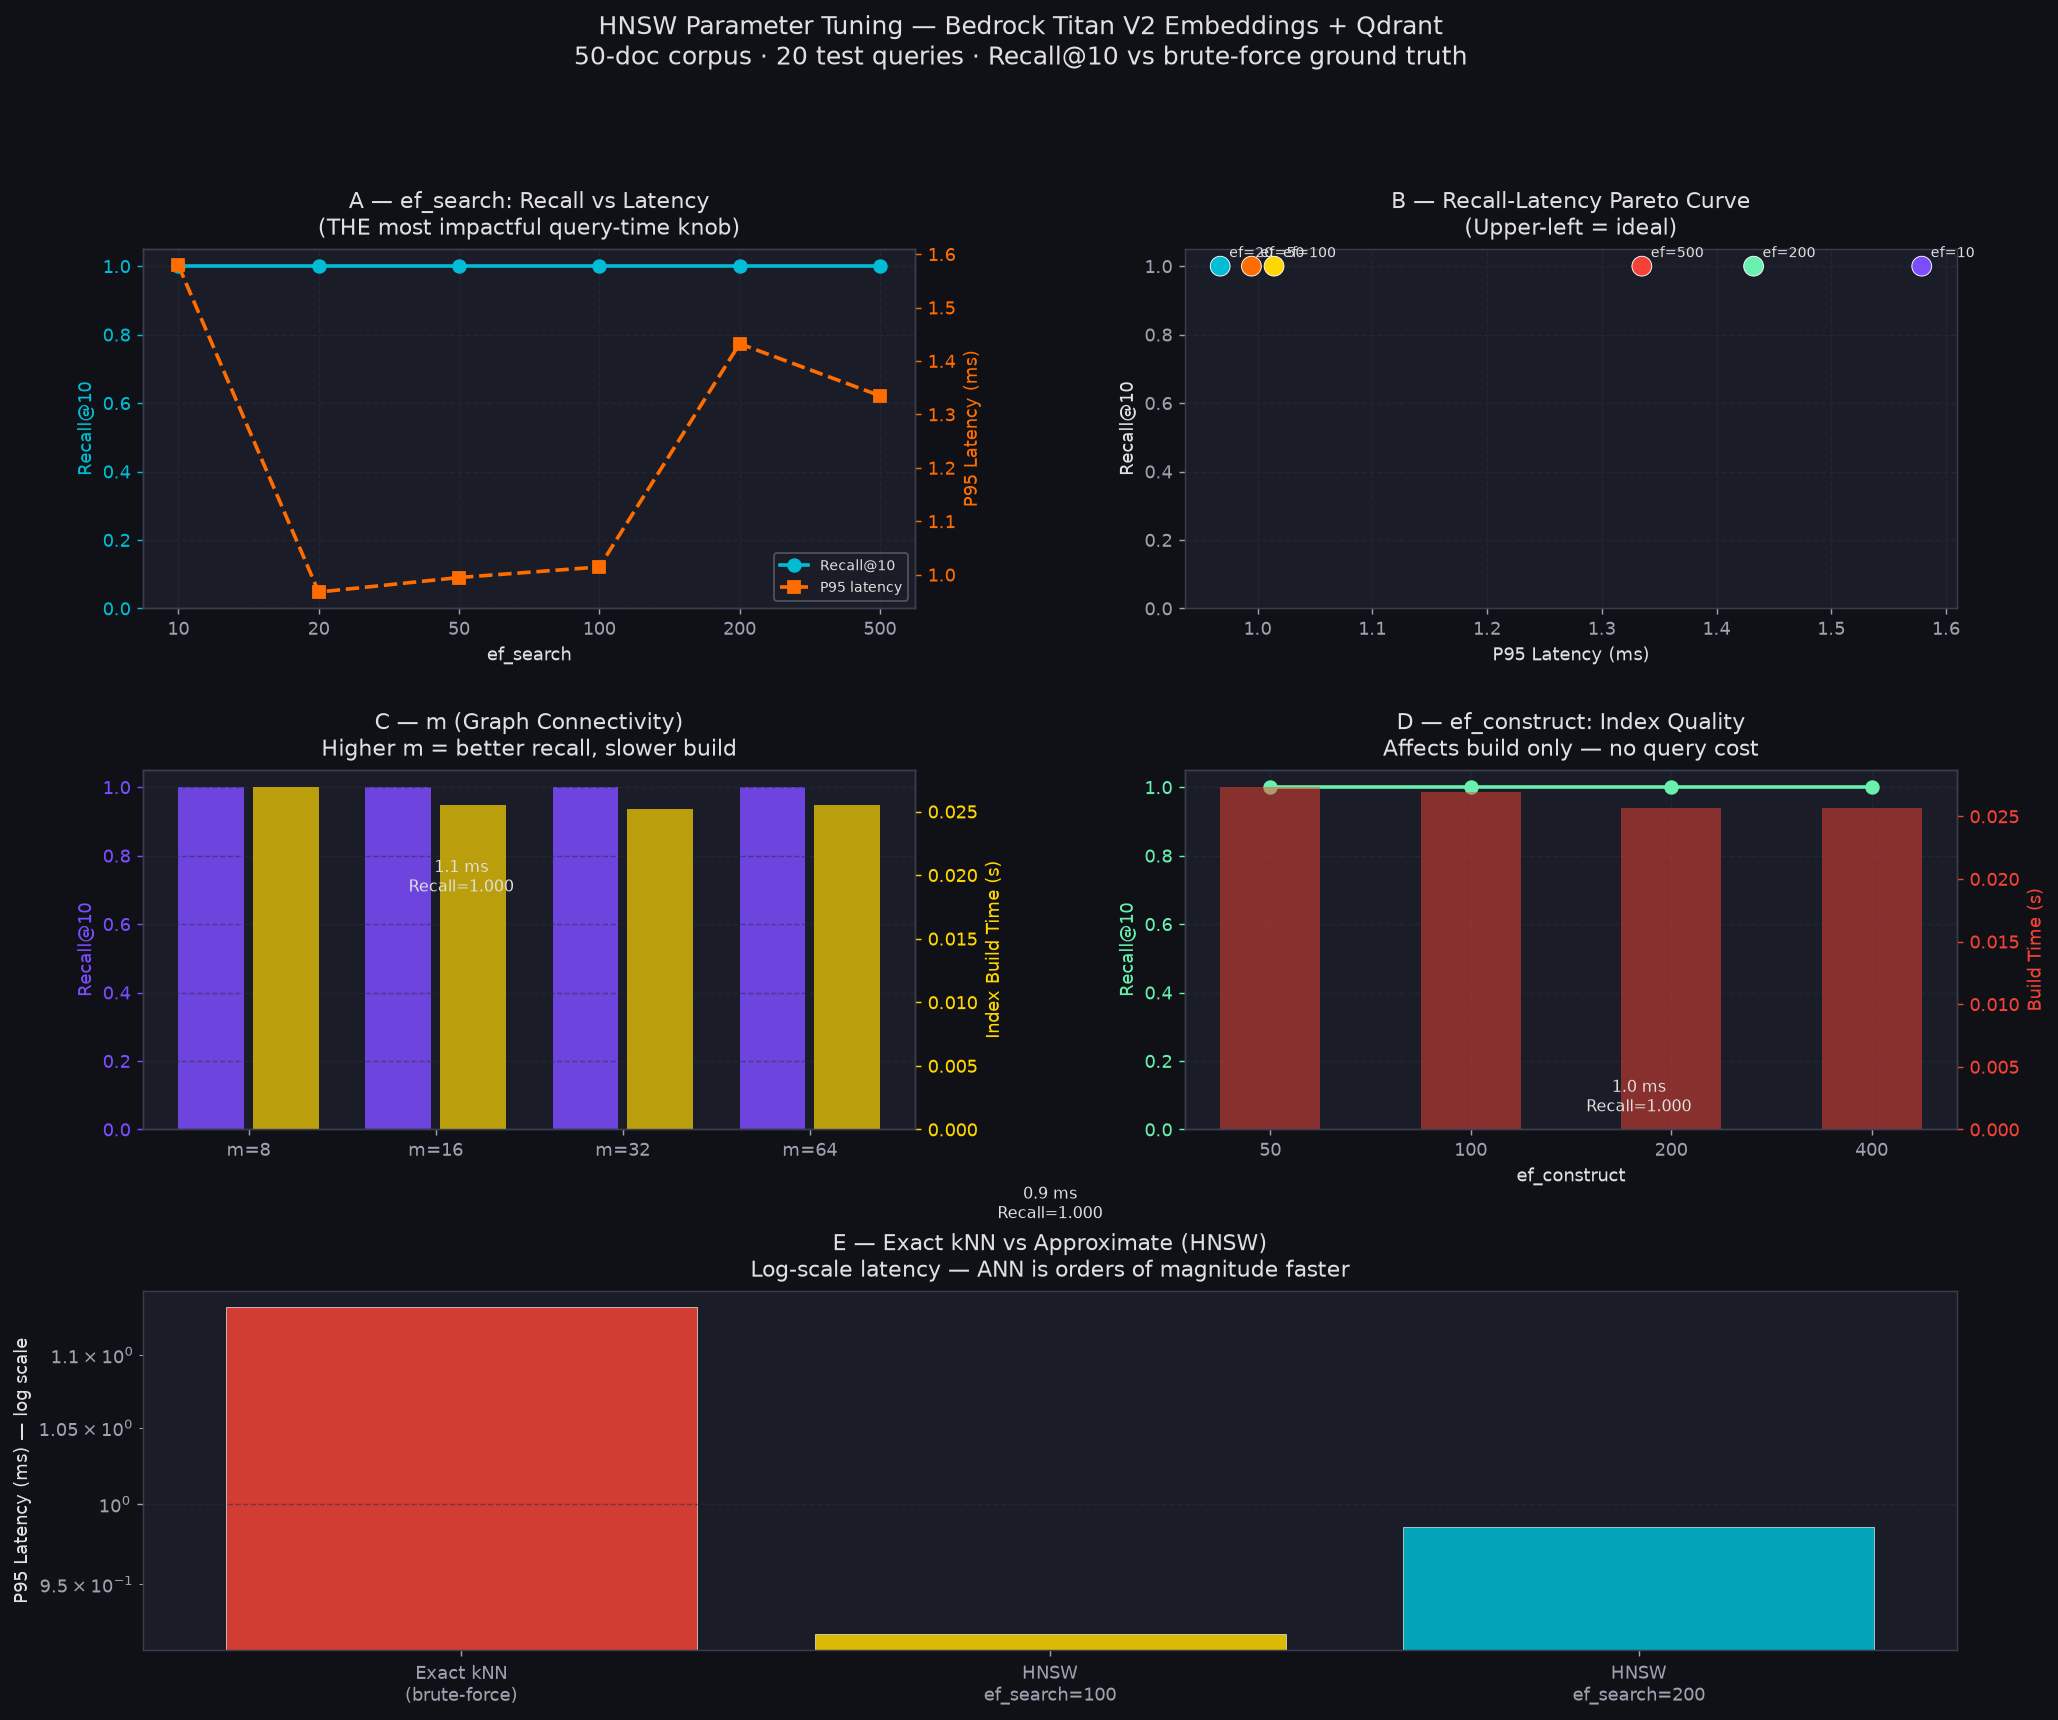

Saved: 04_hnsw_tuning.png


In [11]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ACCENT = ['#7C4DFF', '#00BCD4', '#FF6D00', '#FFD600', '#69F0AE', '#F44336']

# ── Plot A: ef_search dual-axis ───────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a2 = ax_a.twinx()
ax_a2.tick_params(colors='#a0a0b0')
ax_a2.yaxis.label.set_color('#a0a0b0')
ax_a2.spines['right'].set_color('#3a3d4d')
ax_a2.spines['left'].set_color('#3a3d4d')
ax_a2.spines['top'].set_color('#3a3d4d')
ax_a2.spines['bottom'].set_color('#3a3d4d')

x = np.arange(len(EF_SEARCH_VALUES))
ax_a.plot(x, ef_recalls, 'o-', color='#00BCD4', linewidth=2, markersize=7, label='Recall@10')
ax_a2.plot(x, ef_p95s, 's--', color='#FF6D00', linewidth=2, markersize=7, label='P95 latency')
ax_a.set_xticks(x)
ax_a.set_xticklabels(EF_SEARCH_VALUES)
ax_a.set_xlabel('ef_search')
ax_a.set_ylabel('Recall@10', color='#00BCD4')
ax_a.tick_params(axis='y', colors='#00BCD4')
ax_a2.set_ylabel('P95 Latency (ms)', color='#FF6D00')
ax_a2.tick_params(axis='y', colors='#FF6D00')
ax_a.set_title('A — ef_search: Recall vs Latency\n(THE most impactful query-time knob)', pad=8)
ax_a.set_ylim(0, 1.05)
ax_a.grid(True)
lines1, lbl1 = ax_a.get_legend_handles_labels()
lines2, lbl2 = ax_a2.get_legend_handles_labels()
ax_a.legend(lines1 + lines2, lbl1 + lbl2, loc='lower right', framealpha=0.3, fontsize=8)

# ── Plot B: Recall-Latency Pareto scatter ─────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
sc = ax_b.scatter(ef_p95s, ef_recalls, c=ACCENT[:len(EF_SEARCH_VALUES)], s=120, zorder=5,
                  edgecolors='white', linewidths=0.5)
for i, ef in enumerate(EF_SEARCH_VALUES):
    ax_b.annotate(f'ef={ef}', (ef_p95s[i], ef_recalls[i]),
                  xytext=(5, 5), textcoords='offset points', fontsize=8)
ax_b.set_xlabel('P95 Latency (ms)')
ax_b.set_ylabel('Recall@10')
ax_b.set_title('B — Recall-Latency Pareto Curve\n(Upper-left = ideal)', pad=8)
ax_b.set_ylim(0, 1.05)
ax_b.grid(True)

# ── Plot C: m parameter bar chart ────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ax_c2 = ax_c.twinx()
ax_c2.tick_params(colors='#a0a0b0')
ax_c2.spines['right'].set_color('#3a3d4d')
ax_c2.spines['left'].set_color('#3a3d4d')
ax_c2.spines['top'].set_color('#3a3d4d')
ax_c2.spines['bottom'].set_color('#3a3d4d')
x_m = np.arange(len(M_VALUES))
bars = ax_c.bar(x_m - 0.2, m_recalls, 0.35, color='#7C4DFF', alpha=0.85, label='Recall@10')
bars2 = ax_c2.bar(x_m + 0.2, m_builds, 0.35, color='#FFD600', alpha=0.7, label='Build time (s)')
ax_c.set_xticks(x_m)
ax_c.set_xticklabels([f'm={v}' for v in M_VALUES])
ax_c.set_ylabel('Recall@10', color='#7C4DFF')
ax_c.tick_params(axis='y', colors='#7C4DFF')
ax_c2.set_ylabel('Index Build Time (s)', color='#FFD600')
ax_c2.tick_params(axis='y', colors='#FFD600')
ax_c.set_title('C — m (Graph Connectivity)\nHigher m = better recall, slower build', pad=8)
ax_c.set_ylim(0, 1.05)
ax_c.grid(axis='y')

# ── Plot D: ef_construct trade-off ────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
ax_d2 = ax_d.twinx()
ax_d2.tick_params(colors='#a0a0b0')
ax_d2.spines['right'].set_color('#3a3d4d')
ax_d2.spines['left'].set_color('#3a3d4d')
ax_d2.spines['top'].set_color('#3a3d4d')
ax_d2.spines['bottom'].set_color('#3a3d4d')
x_efc = np.arange(len(EFC_VALUES))
ax_d.plot(x_efc, efc_recalls, 'o-', color='#69F0AE', linewidth=2, markersize=7, label='Recall@10')
ax_d2.bar(x_efc, efc_builds, 0.5, color='#F44336', alpha=0.5, label='Build time (s)')
ax_d.set_xticks(x_efc)
ax_d.set_xticklabels([str(v) for v in EFC_VALUES])
ax_d.set_xlabel('ef_construct')
ax_d.set_ylabel('Recall@10', color='#69F0AE')
ax_d.tick_params(axis='y', colors='#69F0AE')
ax_d2.set_ylabel('Build Time (s)', color='#F44336')
ax_d2.tick_params(axis='y', colors='#F44336')
ax_d.set_title('D — ef_construct: Index Quality\nAffects build only — no query cost', pad=8)
ax_d.set_ylim(0, 1.05)
ax_d.grid(True)

# ── Plot E: Exact vs ANN latency (log scale) ──────────────────────────────────
ax_e = fig.add_subplot(gs[2, :])
methods  = ['Exact kNN\n(brute-force)', 'HNSW\nef_search=100', 'HNSW\nef_search=200']
recalls  = [exact_recall, ann_def_recall, ann_recall]
latencies= [exact_p95, ann_def_p95, ann_p95]
colors_e = ['#F44336', '#FFD600', '#00BCD4']

x_e = np.arange(3)
bars_e = ax_e.bar(x_e, latencies, color=colors_e, alpha=0.85, edgecolor='white', linewidth=0.4)
ax_e.set_yscale('log')
ax_e.set_xticks(x_e)
ax_e.set_xticklabels(methods, fontsize=10)
ax_e.set_ylabel('P95 Latency (ms) — log scale')
ax_e.set_title('E — Exact kNN vs Approximate (HNSW)\nLog-scale latency — ANN is orders of magnitude faster', pad=8)
ax_e.grid(axis='y')

for bar, lat, rec in zip(bars_e, latencies, recalls):
    ax_e.text(bar.get_x() + bar.get_width()/2, lat * 1.3,
              f'{lat:.1f} ms\nRecall={rec:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle(
    'HNSW Parameter Tuning — Bedrock Titan V2 Embeddings + Qdrant\n'
    '50-doc corpus · 20 test queries · Recall@10 vs brute-force ground truth',
    fontsize=14, y=1.01
)

plt.savefig('04_hnsw_tuning.png', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved: 04_hnsw_tuning.png')

---
## NVIDIA Perspective — HNSW Parameter Tuning

### NVIDIA's answer to HNSW: CAGRA (GPU-native graph ANN)

HNSW is the CPU gold standard. **CAGRA** is the GPU equivalent — same graph-based ANN idea, built for GPU parallelism.

### CAGRA vs HNSW params (direct mapping)

| HNSW param | CAGRA equivalent | Effect |
|---|---|---|
| `ef_search` | `itopk_size` | Internal queue size — higher = better recall, slower |
| `m` | `graph_degree` | Fixed-degree graph — higher = better recall, more RAM |
| `ef_construct` | `intermediate_graph_degree` | Build quality |
| — | `search_width` | Parent vertices per iteration — throughput tuning |

### DEEP-100M benchmark (H100 GPU)

```
Batch size     CAGRA (GPU)     HNSW (CPU)
-----------------------------------------
1  query       faster          baseline
10 queries     faster          baseline  <- CAGRA wins even tiny batches
10K queries    95x faster      baseline
Index build    95x faster      baseline
```

### IVF-Flat n_probes (same tradeoff as ef_search)

| n_probes | Recall |
|---|---|
| 100 | 96% |
| 1,000 | 99.8% |

NVIDIA rule: `n_probes = 0.1-1% of n_lists` is the sweet spot.

### Workflow: Build GPU -> Serve CPU
> Build index fast on GPU with CAGRA, convert to HNSW format, deploy on CPU servers

**References:**
- [Fine-Tuning GPU Index Algorithms](https://developer.nvidia.com/blog/accelerating-vector-search-fine-tuning-gpu-index-algorithms/)
- [IVF-Flat Deep Dive + Benchmarks](https://developer.nvidia.com/blog/accelerated-vector-search-approximating-with-nvidia-cuvs-ivf-flat/)
- [Optimizing Vector Search with cuVS](https://developer.nvidia.com/blog/optimizing-vector-search-for-indexing-and-real-time-retrieval-with-nvidia-cuvs/)


## Summary — Key Takeaways

| Knob | Rule of thumb | Cost |
|------|---------------|------|
| **ef_search** | Start at 100, raise until recall plateaus. Most impactful, zero re-index. | Query latency only |
| **m** | Default 16 covers most cases. Use 32 for high-recall needs. | Memory + build time |
| **ef_construct** | Set high (200-400) once at index creation. No query cost. | Build time only |

### The fundamental trade-off
```
Exact kNN   →  Perfect recall   +  Seconds latency    (O(N) scan)
HNSW        →  95-99% recall    +  Millisecond latency (O(log N) graph walk)
```

### Recommended starting config for production
```python
HnswConfigDiff(m=16, ef_construct=200)   # index creation
SearchParams(hnsw_ef=100)               # query — raise to 200 if recall < target
```

**Next:** `05_Quantization_Cost_Optimization.ipynb` — reduce memory 4-32× with scalar/binary quantization.